=== МЕТОД 1: Template Matching ===
Метод: TM_CCOEFF_NORMED
Значение совпадения: 0.736
Позиция: (268, 235)


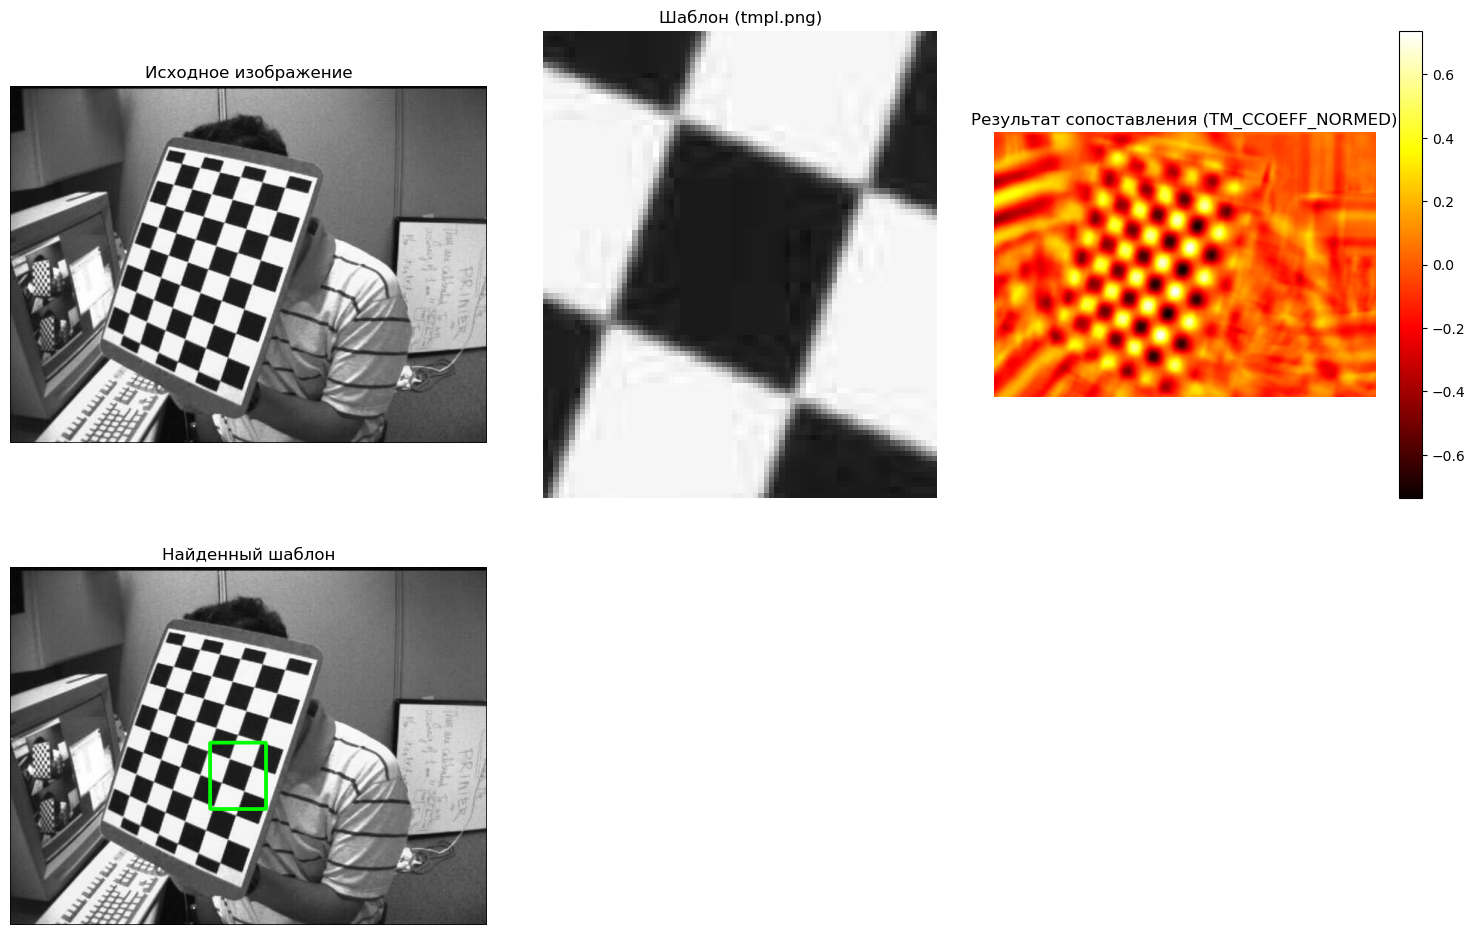

Найдено совпадений выше порога 0.7: 102


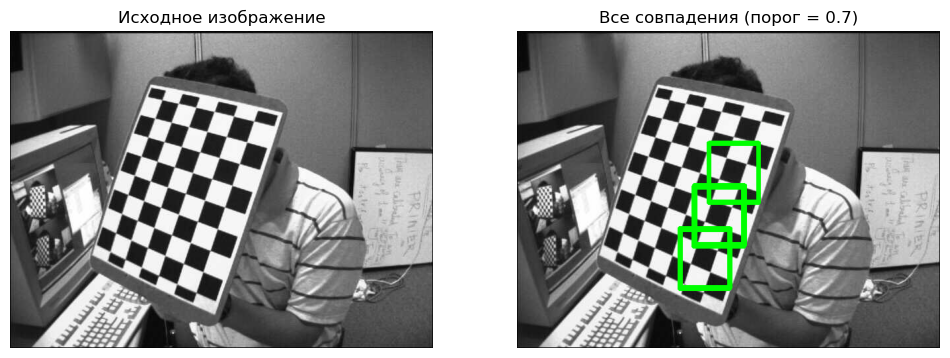

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Загрузка изображения и шаблона
image = cv.imread('./left07.jpg')
template = cv.imread('tmpl.png')

# Конвертация в оттенки серого для лучшего распознавания
image_gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
template_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)

# Получение размеров шаблона
h, w = template_gray.shape

# ===== МЕТОД 1: Сопоставление с шаблоном (Template Matching) =====
print("=== МЕТОД 1: Template Matching ===")

# Список методов сопоставления
methods = [
    ('TM_CCOEFF', cv.TM_CCOEFF),
    ('TM_CCOEFF_NORMED', cv.TM_CCOEFF_NORMED),
    ('TM_CCORR', cv.TM_CCORR),
    ('TM_CCORR_NORMED', cv.TM_CCORR_NORMED),
    ('TM_SQDIFF', cv.TM_SQDIFF),
    ('TM_SQDIFF_NORMED', cv.TM_SQDIFF_NORMED)
]

# Создаем копию изображения для отображения результатов
result_image = image.copy()

# Выбираем лучший метод (обычно TM_CCOEFF_NORMED дает хорошие результаты)
method_name, method = methods[1]  # TM_CCOEFF_NORMED

# Применяем сопоставление с шаблоном
result = cv.matchTemplate(image_gray, template_gray, method)

# Находим наилучшее совпадение
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(result)

# Для методов SQDIFF наименьшее значение = лучшее совпадение
if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
    top_left = min_loc
    match_value = min_val
else:
    top_left = max_loc
    match_value = max_val

bottom_right = (top_left[0] + w, top_left[1] + h)

# Рисуем прямоугольник вокруг найденного шаблона
cv.rectangle(result_image, top_left, bottom_right, (0, 255, 0), 3)

print(f"Метод: {method_name}")
print(f"Значение совпадения: {match_value:.3f}")
print(f"Позиция: {top_left}")

# Визуализация результатов
plt.figure(figsize=(15, 10))

# Исходное изображение
plt.subplot(2, 3, 1)
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.title("Исходное изображение")
plt.axis("off")

# Шаблон
plt.subplot(2, 3, 2)
plt.imshow(cv.cvtColor(template, cv.COLOR_BGR2RGB))
plt.title("Шаблон (tmpl.png)")
plt.axis("off")

# Результат сопоставления (тепловая карта)
plt.subplot(2, 3, 3)
plt.imshow(result, cmap='hot')
plt.colorbar()
plt.title(f"Результат сопоставления ({method_name})")
plt.axis("off")

# Результат с прямоугольником
plt.subplot(2, 3, 4)
plt.imshow(cv.cvtColor(result_image, cv.COLOR_BGR2RGB))
plt.title("Найденный шаблон")
plt.axis("off")

plt.tight_layout()
plt.show()


result_all = cv.matchTemplate(image_gray, template_gray, cv.TM_CCOEFF_NORMED)

# Задаем порог совпадения (чем выше, тем точнее)
threshold = 0.7
locations = np.where(result_all >= threshold)

# Создаем копию для отображения всех совпадений
image_all_matches = image.copy()

# Рисуем прямоугольники вокруг всех найденных совпадений
for pt in zip(*locations[::-1]):
    cv.rectangle(image_all_matches, pt, (pt[0] + w, pt[1] + h), (0, 255, 0), 2)

print(f"Найдено совпадений выше порога {threshold}: {len(locations[0])}")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.title("Исходное изображение")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(image_all_matches, cv.COLOR_BGR2RGB))
plt.title(f"Все совпадения (порог = {threshold})")
plt.axis("off")
plt.show()